# K1 · From Backtest to Paper Trading

A backtest is a simulation of the past under ideal conditions. Paper trading runs the strategy forward in time, with simulated money but real-world frictions. This notebook measures how much performance typically disappears between the two, and why.

## 1. Motivation

The club has a strategy with a good, honest backtest. Before risking real money, it should run for a few months as a **paper portfolio**: real-time signals, simulated orders, a broker's simulated fills. Almost always, the paper results come out worse than the backtest. The question is whether the gap is the normal cost of reality or a sign that the backtest was wrong. To answer it, you need to know what a normal gap looks like and where it comes from.

## 2. Intuition

A backtest quietly assumes a perfect world:

1. **Instant execution.** The trade happens at exactly the price that generated the signal.
2. **Free trading** (unless costs were modelled, notebook 7).
3. **Fractional, unlimited shares.** You can buy 13.7 shares, or exactly 4.21% of the portfolio.
4. **A system that never breaks.** No missed days, no stale data, no crashed scripts.

Live trading breaks each of these a little. The difference between the backtest's return and the return you actually got is called **implementation shortfall**. A good paper-trading setup measures each source separately, so you can tell normal friction from a broken strategy.

## 3. The math

Let $w^{\text{target}}_{t}$ be the backtest's target weights and $w^{\text{actual}}_{t}$ the weights actually held. The live return on day $t+1$ is
$$
R^{\text{live}}_{t+1} = \sum_i w^{\text{actual}}_{i,t}\, R_{i,t+1} \;-\; \underbrace{\sum_i c_i\,\big|\Delta w_{i,t}\big|}_{\text{costs}} .
$$
The **implementation shortfall** over a period is the backtest return minus the live return. We split it into four sources, adding one friction at a time:

| Friction | What changes in the simulation |
|---|---|
| Execution delay | trades fill one day after the signal, at the next close |
| Trading costs | $c$ per unit traded: half spread plus impact (notebook 5) |
| Whole shares | positions rounded down to whole shares, the leftover held as cash |
| Operational misses | on some rebalance days the system fails and no trades happen |

Because each friction is added on top of the previous ones, each step's cost is measured *given* the frictions before it. The order matters slightly, but the total does not.

## 4. Code it

### 4.1 Setup: the strategy

We use a simple, realistic club strategy: each month, hold the 10 stocks with the strongest 12-1 month momentum (SR1) in equal weights, long only.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

stocks = meta.loc[meta.asset_type == "stock", "ticker"]
px = prices[stocks].loc["2011":]
ret = px.pct_change().fillna(0)

# Target weights, decided at each month-end close
mom = prices[stocks].shift(21) / prices[stocks].shift(252) - 1
month_ends = px.groupby(px.index.to_period("M")).tail(1).index
targets = {}
for d in month_ends:
    top10 = mom.loc[d].nlargest(10).index
    targets[d] = pd.Series(0.1, index=top10).reindex(stocks, fill_value=0.0)
targets = pd.DataFrame(targets).T
print(f"{len(targets)} monthly rebalances; example (last month):")
print(targets.iloc[-1][targets.iloc[-1] > 0].index.tolist())

189 monthly rebalances; example (last month):
['CSCO', 'GOOGL', 'KO', 'JNJ', 'MRK', 'XOM', 'CVX', 'COP', 'SLB', 'CAT']


### 4.2 A simulator that adds frictions one at a time

The simulator steps through every trading day, tracks cash and share holdings, and trades on rebalance days. Each friction is a switch.

In [2]:
def simulate(capital=100_000, delay=0, cost_bps=0.0, whole_shares=False, miss_prob=0.0, seed=0):
    rng = np.random.default_rng(seed)
    dates = px.index
    shares = pd.Series(0.0, index=stocks)
    cash = capital
    values, pending = [], None
    for k, d in enumerate(dates):
        p = px.loc[d]
        if d in targets.index:
            pending = (targets.loc[d], k + delay)            # signal decided at this close
        if pending is not None and k == pending[1]:          # time to execute
            target_w, _ = pending
            pending = None
            if rng.random() >= miss_prob:                     # operational miss: skip this rebalance
                value = cash + (shares * p).sum()
                new_shares = target_w * value / p
                if whole_shares:
                    new_shares = np.floor(new_shares)
                traded_value = ((new_shares - shares).abs() * p).sum()
                cash -= ((new_shares - shares) * p).sum()      # pay for buys, receive sales
                cash -= traded_value * cost_bps / 1e4          # trading costs
                shares = new_shares
        values.append(cash + (shares * p).sum())
    return pd.Series(values, index=dates)

scenarios = {
    "1. Backtest (ideal)":           dict(),
    "2. + 1-day execution delay":    dict(delay=1),
    "3. + 10 bp trading costs":      dict(delay=1, cost_bps=10),
    "4. + whole shares ($100k)":     dict(delay=1, cost_bps=10, whole_shares=True),
    "5. + 5% missed rebalances":     dict(delay=1, cost_bps=10, whole_shares=True, miss_prob=0.05),
}
runs = pd.DataFrame({name: simulate(**kw) for name, kw in scenarios.items()})

### 4.3 Where does the performance go?

In [3]:
years = len(runs) / 252
cagr = (runs.iloc[-1] / runs.iloc[0]) ** (1 / years) - 1
r = runs.pct_change().dropna()
table = pd.DataFrame({
    "CAGR": cagr.map("{:.2%}".format),
    "Sharpe": (np.sqrt(252) * r.mean() / r.std()).map("{:.2f}".format),
    "Cost of this step (% per year)": (-cagr.diff()).map(lambda x: "" if pd.isna(x) else f"{x:.2%}"),
})
table

,CAGR,Sharpe,Cost of this step (% per year)
1. Backtest (ideal),18.39%,0.95,
2. + 1-day execution delay,17.89%,0.93,0.50%
3. + 10 bp trading costs,17.24%,0.90,0.66%
4. + whole shares ($100k),17.22%,0.90,0.02%
5. + 5% missed rebalances,17.57%,0.92,-0.35%


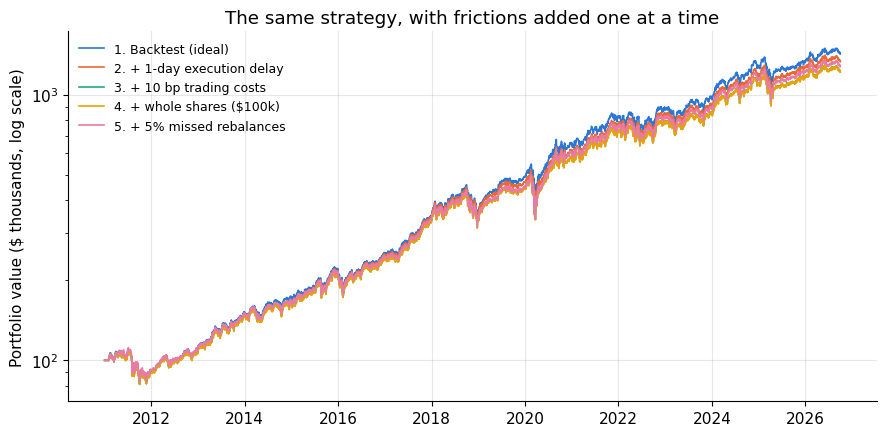

In [4]:
fig, ax = plt.subplots()
for col, c in zip(runs, COLORS):
    ax.plot(runs.index, runs[col] / 1000, label=col, color=c, linewidth=1.2)
ax.set_yscale("log")
ax.set_ylabel("Portfolio value ($ thousands, log scale)")
ax.set_title("The same strategy, with frictions added one at a time")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Reading down the table:

- **Execution delay costs about 0.5% a year.** Trading one day after the signal means missing part of the move the signal predicted.
- **Trading costs at 10 bp cost about 0.65% a year.** This strategy replaces several of its 10 stocks each month.
- **Whole shares cost almost nothing** with &#36;100,000. With &#36;5,000, rounding would leave much more cash idle and skew the weights.
- **Missed rebalances *helped* in this run** (+0.35%), purely by luck: skipping some months happened to keep winners longer. The next cell shows it can go either way.

In total, the realistic version earns about 0.8 percentage points a year less than the ideal backtest, with almost the same Sharpe ratio. For a monthly strategy, that is a normal, healthy gap. A paper account showing a gap of 5% a year would point to a bug or a flawed backtest, not to friction.

Step 5 depends on *which* rebalances were missed, which is luck. Re-running it with 20 different random seeds shows the range:

In [5]:
base = cagr["4. + whole shares ($100k)"]
miss_effects = []
for seed in range(20):
    v = simulate(delay=1, cost_bps=10, whole_shares=True, miss_prob=0.05, seed=seed)
    miss_effects.append((v.iloc[-1] / v.iloc[0]) ** (1 / years) - 1 - base)
miss_effects = np.array(miss_effects)
print(f"Effect of 5% missed rebalances on CAGR, over 20 seeds: "
      f"from {miss_effects.min():+.2%} to {miss_effects.max():+.2%} per year (median {np.median(miss_effects):+.2%})")

Effect of 5% missed rebalances on CAGR, over 20 seeds: from -0.43% to +0.64% per year (median +0.09%)


Missing 5% of rebalances changes the annual return by anything from about −0.4 to +0.6 percentage points, depending on *which* months are missed, with a median close to zero. Operational failures don't cost much on average, but they add noise that can't be diversified away within one portfolio. With a few months of paper trading, this noise alone can hide or fake a difference between strategies.

### 4.4 What a real paper account looks like

A broker's paper-trading account gives you the real-time version of this simulator. The code below shows the shape of a monthly rebalance with the Alpaca API (free paper accounts). It is *not run* here, because it needs an account and API keys, which must never be stored in a notebook or committed to git.
```python
import os
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest
from alpaca.trading.enums import OrderSide, TimeInForce

client = TradingClient(os.environ["ALPACA_KEY"], os.environ["ALPACA_SECRET"], paper=True)  # paper=True: no real money

account = client.get_account()
equity = float(account.equity)
current = {p.symbol: float(p.qty) for p in client.get_all_positions()}

for ticker, weight in target_weights.items():                 # from the strategy
    price = latest_price[ticker]
    target_qty = int(weight * equity / price)                   # whole shares
    diff = target_qty - current.get(ticker, 0)
    if diff != 0:
        client.submit_order(MarketOrderRequest(symbol=ticker, qty=abs(diff),
                            side=OrderSide.BUY if diff > 0 else OrderSide.SELL,
                            time_in_force=TimeInForce.DAY))
```
The essential extras around this core: **log** every signal, order and fill; **reconcile** daily (do the broker's positions match what the system thinks it holds?); and keep a **kill switch** that stops all trading if something looks wrong.

## 5. Takeaways and where it breaks

- **Expect a gap.** Some loss between backtest and paper trading is normal. Measure it source by source instead of judging the total.
- **For slow strategies, costs and delays are small.** This monthly momentum strategy lost a little over 1% a year to delay and costs. A daily strategy would lose far more (notebook 7).
- **Operational failures are random and lumpy.** One missed rebalance can matter more than a year of trading costs, depending on luck. Logging and monitoring matter as much as the model.
- **Where it breaks:** our simulator still fills at closing prices and assumes our orders don't move the market. A paper account is better, but its fills are also simulated and usually optimistic, especially for illiquid stocks. Only live trading with small size gives the real numbers.
- **Paper trading tests the system, not just the strategy.** A few months of paper results say little about the strategy's long-run edge (a Sharpe ratio needs years to measure), but a lot about whether the code, data and process work.

**What you could build:** a paper-trading deployment of one strategy from each team, with a daily dashboard showing backtest vs. paper returns and the shortfall broken down by source.